
# Geographic Access Analysis: Distance to Nearest Burn Center

## Goal
Measure how far trauma hospitals are from the nearest burn center to identify referral gaps that may delay burn treatment.



## Workflow
1. Load hospital dataset
2. Create full address
3. Geocode hospitals (cached so it only runs once)
4. Identify trauma hospitals and burn centers
5. Calculate distance to nearest burn center
6. Compute metrics and export results


## Imports

In [1]:

import pandas as pd
import numpy as np
from math import radians, sin, cos, sqrt, atan2
from pathlib import Path


## Load Dataset

In [2]:
file_path = Path("../data/NIRD 20230130 Database_Hackathon.xlsx")
sheet_name = "Data Table NIRD 20230130"
df = pd.read_excel(file_path, sheet_name=sheet_name)

df

,STATE_FULL,STATE,COUNTY,ADDRESS,CITY,ZIP_CODE,AHA_ID,HOSPITAL_NAME,TOTAL_BEDS,BURN_BEDS,...,BURN_PEDS,ACS_VERIFIED,ADULT_TRAUMA_L1,ADULT_TRAUMA_L2,PEDS_TRAUMA_L1,PEDS_TRAUMA_L2,ABA_VERIFIED,TC_STATE_DESIGNATED,BC_STATE_DESIGNATED,PHONE
0,Alaska,AK,Anchorage,4315 Diplomacy Dr,Anchorage,99508,6940010.0,Alaska Native Medical Center,173,NaN,...,NaN,Yes,NaN,1.0,NaN,1.0,NaN,Yes,NaN,(907) 563-2662
1,Alaska,AK,Anchorage,3200 Providence Dr,Anchorage,99508,6940020.0,Providence Alaska Medical Center/Children's Ho...,401,NaN,...,NaN,Yes,NaN,1.0,NaN,1.0,NaN,Yes,NaN,(907) 562-2211
2,Alabama,AL,Houston,1108 Ross Clark Cir,Dothan,36301,6530373.0,Southeast Alabama Medical Center,387,NaN,...,NaN,No,NaN,1.0,NaN,NaN,NaN,Yes,NaN,(334) 793-8111
3,Alabama,AL,Jefferson,619 19th St S,Birmingham,35233,6530304.0,University of Alabama at Birmingham Hospital (...,1157,28.0,...,NaN,Yes,1.0,NaN,NaN,NaN,No,Yes,No,(205) 934-3411
4,Alabama,AL,Jefferson,1600 7th Ave South,Birmingham,35233,6530170.0,Children's of Alabama (Children's of Alabama B...,351,6.0,...,1.0,No,NaN,NaN,1.0,NaN,No,Yes,No,(205) 638-9100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
630,Wisconsin,WI,Milwaukee,2301 North Lake Dr,Milwaukee,53211,6451130.0,Ascension Columbia St. Mary's Hospital Regiona...,273,12.0,...,1.0,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,(414) 585-1163
631,Wisconsin,WI,Rock,1000 Mineral Point Ave,Janesville,53547,6450015.0,Mercyhealth Hospital and Trauma Center,240,NaN,...,NaN,Yes,NaN,1.0,NaN,NaN,NaN,Yes,NaN,(608) 314-3605
632,Wisconsin,WI,Waukesha,36500 Aurora Dr,Summit,53066,6450175.0,Aurora Medical Center Summit,117,NaN,...,NaN,Yes,NaN,1.0,NaN,NaN,NaN,Yes,NaN,(262) 434-1000
633,Wisconsin,WI,Winnebago,130 2nd St,Neenah,54956,6451290.0,ThedaCare Regional Medical Center - Neenah,150,NaN,...,NaN,Yes,NaN,1.0,NaN,NaN,NaN,Yes,NaN,(920) 729-2155


## Create Full Address for Geocoding

In [3]:

df["FULL_ADDRESS"] = (
    df["ADDRESS"].astype(str) + ", " +
    df["CITY"].astype(str) + ", " +
    df["STATE"].astype(str) + " " +
    df["ZIP_CODE"].astype(str)
)

df[["HOSPITAL_NAME","FULL_ADDRESS"]].head()


,HOSPITAL_NAME,FULL_ADDRESS
0,Alaska Native Medical Center,"4315 Diplomacy Dr, Anchorage, AK 99508"
1,Providence Alaska Medical Center/Children's Ho...,"3200 Providence Dr, Anchorage, AK 99508"
2,Southeast Alabama Medical Center,"1108 Ross Clark Cir, Dothan, AL 36301"
3,University of Alabama at Birmingham Hospital (...,"619 19th St S, Birmingham, AL 35233"
4,Children's of Alabama (Children's of Alabama B...,"1600 7th Ave South, Birmingham, AL 35233"



## Geocoding Function (Cached)

This function:
- Geocodes hospital addresses
- Saves the results to a CSV file
- Loads the CSV automatically next time so geocoding runs **only once**


In [4]:

def geocode_and_cache(df, address_col="FULL_ADDRESS", cache_file="../outputs/hospital_geocoded.csv"):
    
    import os
    import time
    from geopy.geocoders import Nominatim
    
    if os.path.exists(cache_file):
        print("Loading cached geocoded data...")
        return pd.read_csv(cache_file)
    
    print("Geocoding addresses (this runs only once)...")
    
    geolocator = Nominatim(user_agent="burn_access_analysis", timeout=5)
    
    latitudes = []
    longitudes = []
    
    for address in df[address_col]:
        try:
            location = geolocator.geocode(address)
            
            if location:
                latitudes.append(location.latitude)
                longitudes.append(location.longitude)
            else:
                latitudes.append(None)
                longitudes.append(None)
            
            time.sleep(1)
            
        except:
            latitudes.append(None)
            longitudes.append(None)
    
    df["LATITUDE"] = latitudes
    df["LONGITUDE"] = longitudes
    
    df.to_csv(cache_file, index=False)
    
    print("Geocoded data saved to:", cache_file)
    
    return df


## Run Geocoding (Run Once)

In [5]:

df = geocode_and_cache(df)

df.head()


Loading cached geocoded data...


,STATE_FULL,STATE,COUNTY,ADDRESS,CITY,ZIP_CODE,AHA_ID,HOSPITAL_NAME,TOTAL_BEDS,BURN_BEDS,...,ADULT_TRAUMA_L2,PEDS_TRAUMA_L1,PEDS_TRAUMA_L2,ABA_VERIFIED,TC_STATE_DESIGNATED,BC_STATE_DESIGNATED,PHONE,FULL_ADDRESS,LATITUDE,LONGITUDE
0,Alaska,AK,Anchorage,4315 Diplomacy Dr,Anchorage,99508,6940010.0,Alaska Native Medical Center,173,NaN,...,1.0,NaN,1.0,NaN,Yes,NaN,(907) 563-2662,"4315 Diplomacy Dr, Anchorage, AK 99508",61.182772,-149.800177
1,Alaska,AK,Anchorage,3200 Providence Dr,Anchorage,99508,6940020.0,Providence Alaska Medical Center/Children's Ho...,401,NaN,...,1.0,NaN,1.0,NaN,Yes,NaN,(907) 562-2211,"3200 Providence Dr, Anchorage, AK 99508",61.187168,-149.819439
2,Alabama,AL,Houston,1108 Ross Clark Cir,Dothan,36301,6530373.0,Southeast Alabama Medical Center,387,NaN,...,1.0,NaN,NaN,NaN,Yes,NaN,(334) 793-8111,"1108 Ross Clark Cir, Dothan, AL 36301",31.214885,-85.361261
3,Alabama,AL,Jefferson,619 19th St S,Birmingham,35233,6530304.0,University of Alabama at Birmingham Hospital (...,1157,28.0,...,NaN,NaN,NaN,No,Yes,No,(205) 934-3411,"619 19th St S, Birmingham, AL 35233",33.506101,-86.801782
4,Alabama,AL,Jefferson,1600 7th Ave South,Birmingham,35233,6530170.0,Children's of Alabama (Children's of Alabama B...,351,6.0,...,NaN,1.0,NaN,No,Yes,No,(205) 638-9100,"1600 7th Ave South, Birmingham, AL 35233",33.504689,-86.805635


## Identify Trauma Hospitals and Burn Centers

In [6]:

trauma = df[
    (df["TRAUMA_ADULT"].notna()) | 
    (df["TRAUMA_PEDS"].notna())
].copy()

burn_centers = df[
    (df["BURN_ADULT"].notna()) | 
    (df["BURN_PEDS"].notna())
].copy()

print("Trauma hospitals:", len(trauma))
print("Burn centers:", len(burn_centers))


Trauma hospitals: 616
Burn centers: 136


## Remove Hospitals Without Coordinates

In [7]:

trauma = trauma.dropna(subset=["LATITUDE","LONGITUDE"])
burn_centers = burn_centers.dropna(subset=["LATITUDE","LONGITUDE"])


## Haversine Distance Function

In [8]:

def haversine(lat1, lon1, lat2, lon2):
    
    R = 3958.8
    
    lat1, lon1, lat2, lon2 = map(
        radians, [lat1, lon1, lat2, lon2]
    )
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    
    return R * c


## Calculate Distance to Nearest Burn Center

In [9]:

nearest_distances = []

for _, t in trauma.iterrows():
    
    distances = burn_centers.apply(
        lambda b: haversine(
            t["LATITUDE"], t["LONGITUDE"],
            b["LATITUDE"], b["LONGITUDE"]
        ),
        axis=1
    )
    
    nearest_distances.append(distances.min())

trauma["nearest_burn_distance_miles"] = nearest_distances

display(trauma.head())


,STATE_FULL,STATE,COUNTY,ADDRESS,CITY,ZIP_CODE,AHA_ID,HOSPITAL_NAME,TOTAL_BEDS,BURN_BEDS,...,PEDS_TRAUMA_L1,PEDS_TRAUMA_L2,ABA_VERIFIED,TC_STATE_DESIGNATED,BC_STATE_DESIGNATED,PHONE,FULL_ADDRESS,LATITUDE,LONGITUDE,nearest_burn_distance_miles
0,Alaska,AK,Anchorage,4315 Diplomacy Dr,Anchorage,99508,6940010.0,Alaska Native Medical Center,173,NaN,...,NaN,1.0,NaN,Yes,NaN,(907) 563-2662,"4315 Diplomacy Dr, Anchorage, AK 99508",61.182772,-149.800177,1430.846678
1,Alaska,AK,Anchorage,3200 Providence Dr,Anchorage,99508,6940020.0,Providence Alaska Medical Center/Children's Ho...,401,NaN,...,NaN,1.0,NaN,Yes,NaN,(907) 562-2211,"3200 Providence Dr, Anchorage, AK 99508",61.187168,-149.819439,1431.555391
2,Alabama,AL,Houston,1108 Ross Clark Cir,Dothan,36301,6530373.0,Southeast Alabama Medical Center,387,NaN,...,NaN,NaN,NaN,Yes,NaN,(334) 793-8111,"1108 Ross Clark Cir, Dothan, AL 36301",31.214885,-85.361261,166.113362
3,Alabama,AL,Jefferson,619 19th St S,Birmingham,35233,6530304.0,University of Alabama at Birmingham Hospital (...,1157,28.0,...,NaN,NaN,No,Yes,No,(205) 934-3411,"619 19th St S, Birmingham, AL 35233",33.506101,-86.801782,0.000000
4,Alabama,AL,Jefferson,1600 7th Ave South,Birmingham,35233,6530170.0,Children's of Alabama (Children's of Alabama B...,351,6.0,...,1.0,NaN,No,Yes,No,(205) 638-9100,"1600 7th Ave South, Birmingham, AL 35233",33.504689,-86.805635,0.000000


## Key Metrics

In [10]:

avg_distance = trauma["nearest_burn_distance_miles"].mean()

over_50 = trauma[trauma["nearest_burn_distance_miles"] > 50]
over_100 = trauma[trauma["nearest_burn_distance_miles"] > 100]

print("Average distance to burn center:", round(avg_distance,2),"miles")
print("Hospitals > 50 miles:", len(over_50))
print("Hospitals > 100 miles:", len(over_100))


Average distance to burn center: 41.4 miles
Hospitals > 50 miles: 144
Hospitals > 100 miles: 56


## Visualization 1: Distribution of Distance to Burn Centers
This histogram shows how far trauma hospitals are from the nearest burn center.

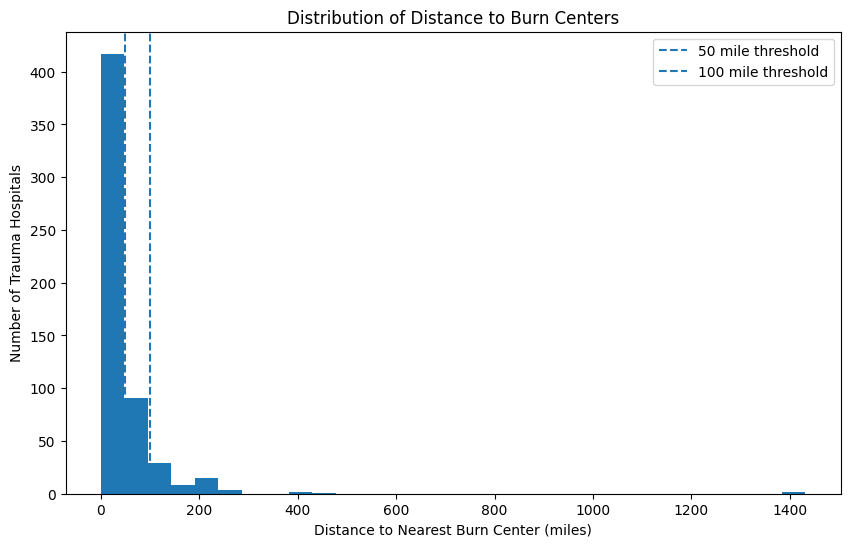

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    trauma["nearest_burn_distance_miles"],
    bins=30
)

plt.axvline(50, linestyle="--", label="50 mile threshold")
plt.axvline(100, linestyle="--", label="100 mile threshold")

plt.xlabel("Distance to Nearest Burn Center (miles)")
plt.ylabel("Number of Trauma Hospitals")
plt.title("Distribution of Distance to Burn Centers")

plt.legend()

plt.show()

## Visualization 2: Geographic Referral Gap Map
Hospitals farther than 50 miles from burn care are highlighted.

In [12]:
import folium

# create base map
m = folium.Map(location=[39, -98], zoom_start=4)

# burn centers (red)
for _, row in burn_centers.iterrows():

    folium.Marker(
        location=[row["LATITUDE"], row["LONGITUDE"]],
        popup=row["HOSPITAL_NAME"],
        icon=folium.Icon(color="red", icon="map-marker", prefix="fa")
    ).add_to(m)


# trauma hospitals > 50 miles (blue)
gap_hospitals = trauma[trauma["nearest_burn_distance_miles"] > 50]

for _, row in gap_hospitals.iterrows():

    folium.Marker(
        location=[row["LATITUDE"], row["LONGITUDE"]],
        popup=row["HOSPITAL_NAME"],
        icon=folium.Icon(color="blue", icon="map-marker", prefix="fa")
    ).add_to(m)

m

## Identify Trauma Hospitals

In [13]:
trauma = df[df['TRAUMA_ADULT'] == 1].copy()
print('Trauma hospitals:', len(trauma))

Trauma hospitals: 565


## Identify Burn Centers

In [14]:
burn_centers = df[(df['BURN_ADULT'] == 1) | (df['BURN_PEDS'] == 1)].copy()
print('Burn centers:', len(burn_centers))

Burn centers: 136


## Compute Nearest Burn Center

In [15]:
nearest_centers = []

for _, trauma_hospital in trauma.iterrows():

    min_distance = float('inf')
    nearest_center = None

    for _, burn in burn_centers.iterrows():

        distance = haversine(
            trauma_hospital['LATITUDE'], trauma_hospital['LONGITUDE'],
            burn['LATITUDE'], burn['LONGITUDE']
        )

        if pd.notna(distance) and distance < min_distance:
            min_distance = distance
            nearest_center = burn['HOSPITAL_NAME']

    if min_distance == float('inf'):
        min_distance = np.nan

    nearest_centers.append({
        'HOSPITAL_NAME': trauma_hospital['HOSPITAL_NAME'],
        'CITY': trauma_hospital['CITY'],
        'STATE_FULL': trauma_hospital['STATE_FULL'],
        'LATITUDE': trauma_hospital['LATITUDE'],
        'LONGITUDE': trauma_hospital['LONGITUDE'],
        'nearest_burn_center': nearest_center,
        'nearest_burn_distance_miles': min_distance
    })

distance_results = pd.DataFrame(nearest_centers)

distance_results['nearest_burn_distance_miles'].describe()

count     522.000000
mean       44.001797
std       104.412246
min         0.000000
25%         1.862579
50%        14.476194
75%        55.171137
max      1431.555391
Name: nearest_burn_distance_miles, dtype: float64

## Create Distance Score

In [16]:
distance_results['distance_score'] = (
    distance_results['nearest_burn_distance_miles'].astype(float) /
    float(distance_results['nearest_burn_distance_miles'].max())
)

## Export Results for Analysis 4

In [17]:
analysis2_output = distance_results[[
    'HOSPITAL_NAME',
    'CITY',
    'STATE_FULL',
    'LATITUDE',
    'LONGITUDE',
    'nearest_burn_center',
    'nearest_burn_distance_miles',
    'distance_score'
]]

output_dir = Path('../outputs')
output_dir.mkdir(parents=True, exist_ok=True)

analysis2_output.to_csv(
    output_dir / 'analysis2_distance_results.csv',
    index=False
)

print('Analysis 2 results exported to:', output_dir)

Analysis 2 results exported to: ..\outputs
